<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Predicci%C3%B3n_de_cancelaci%C3%B3n_de_reservas_con_redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predicción de cancelación de reserva

## El Problema

Las cancelaciones de reservas no son solo un "trámite administrativo"; para una cadena de hoteles, representan una de las mayores fugas de rentabilidad y un dolor de cabeza operativo. El problema ha empeorado con la cultura de la "multireserva" (clientes que reservan en varios hoteles para decidirse al final), impulsada por las políticas flexibles de las OTAs (Online Travel Agencies) como Booking o Expedia

## Objetivo

El objetivo es predecir si un cliente cancelará o no la reserva realizada.

## Diccionario de Datos

* **hotel:** Hotel (H1 = Resort Hotel o H2 = City Hotel)
* **is_canceled:** Valor que indica si la reserva se canceló (1) o no (0).
* **lead_time:** Número de días transcurridos entre la fecha de entrada de la reserva en el PMS y la fecha de llegada
* **arrival_date_year:** Año de la fecha de llegada
* **arrival_date_month:** Mes de la fecha de llegada
* **arrival_date_week_number:** Número de semana del año de la fecha de llegada
* **arrival_date_day_of_month:** Día de la fecha de llegada
* **stays_in_weekend_nights:** Número de noches de fin de semana (sábado o domingo) que el huésped se alojó o reservó para alojarse en el hotel.
* **stays_in_week_nights:** Número de noches entre semana (de lunes a viernes) que el cliente se alojó o reservó en el hotel.
* **adults:** Número de adultos
* **children:** Número de niños
* **babies:** Número de bebés
* **meal:** Tipo de comida reservada. Las categorías se presentan en paquetes de
comidas de hospitalidad estándar:

        Undefined/SC - sin paquete de comidas;
        BB - Alojamiento y desayuno;
        HB - Media pensión (desayuno y otra comida - normalmente cena);
        FB - Pensión completa (desayuno, almuerzo y cena)
* **country:** País de origen. Las categorías se representan en el formato ISO
3155-3:2013
* **market_segment:** Designación del segmento de mercado. En las categorías, el
término TA significa agencias de viaje y TO operadores turísticos.
* **distribution_channel:** Canal de distribución de reservas. En las categorías, el término TA significa agencias de viaje y TO operadores turísticos.
* **is_repeated_guest:** Valor que indica si el nombre de la reserva era de un huésped repetido (1) o no (0)
* **previous_cancellations:** Número de reservas anteriores canceladas por el cliente antes de la reserva actual
* **previous_bookings_not_canceled:** Número de reservas anteriores no canceladas por el cliente antes de la reserva actual.
reserved_room_type: Código del tipo de habitación reservada. El código se presenta
en lugar de la designación por razones de anonimato.
* **assigned_room_type:** Código del tipo de habitación asignado a la reserva
* **booking_changes:** Número de cambios/enmiendas realizados en la reserva desde el momento en que se introdujo en el PMS
* **deposit_type:** Indicación de si el cliente hizo un depósito para garantizar la reserva.
Esta variable puede asumir tres categorías:

        No Deposit: no se realizó ningún depósito;
        No Refund: se realizó un depósito por valor del coste total de la estancia;
        Refundable: se realizó un depósito por valor inferior al coste total de la estancia.

* **agent:** ID de la agencia de viajes que realizó la reserva
* **company:** ID de la empresa/entidad que realizó la reserva o responsable del pago de la reserva. La identificación se presenta en lugar de la designación por razones de anonimato.
* **days_in_waiting_list:** Número de días que la reserva estuvo en lista de espera antes de ser confirmada al cliente
* **customer_type:** Tipo de reserva, asumiendo una de las cuatro categorías:

           Contract: cuando la reserva tiene asociada una adjudicación u otro tipo de contrato;
           Group :  cuando la reserva está asociada a un grupo;
           Transient :  cuando la reserva no forma parte de un grupo o contrato, y no está asociada a otra reserva transitoria;
           Transient party :  cuando la reserva es transitoria, pero está asociada al menos a otra reserva transitoria.

* **adr:** Tarifa media diaria definida dividiendo la suma de todas las transacciones de alojamiento por el número total de noches de estancia.
* **required_car_parking_spaces:** Número de plazas de aparcamiento que necesita el cliente
* **total_of_special_requests:** Número de peticiones especiales realizadas por el cliente (por ejemplo, cama doble o piso alto)
* **reservation_status:** Último estado de la reserva, asumiendo una de las tres categorías:

          Canceled: el cliente ha cancelado la reserva;
          Check-Out: el cliente se ha registrado pero ya se ha marchado;
          No-Show: el cliente no se ha registrado y ha informado al hotel del motivo.
* **reservation_status_date:** Fecha en la que se estableció el último estado. Esta variable se puede utilizar junto con ReservationStatus para saber cuándo se cancela la reserva o cuándo abandona el cliente el hotel.


## Metodología

1. En primera instancia se procederá a importar las libreriías necearias para aplicar el preprocesamiento de datos, visualización y creación de un modelo de red nuronal feedforward
2. A continuación se descartarán las columnas **index**, **arrival_date_year**, **agent**, **country**, **company**, **reservation_status** y **reservation_status_date** y se verificará la presencia de datos ausentes (NaN). En caso que existan, estos registros serán eliminados siempre y cuando la cantidad sea menor al 4% del total. En caso que sea superior, se decidirá en función de cada uno ellos, si se prescinde de la característica o si se imputan los datos faltantes describiendo y aplicando alguna estrategía para tales fines.
3. Se realizará un análisis descriptivo y prepara los datos. Para esto:

    **a.** Se Seleccionarán 5 variables que que sean considas relevantes (que no sean la variable **adr**) con respecto a cancelar una reserva.
    
    **b.** Se construirá un histograma para la variable adr con reservas canceladas y no canceladas, comentando el resultado obtenido.
    
    **c.** Se verificará la presencia de outlier para la variable adr. En caso que presente valores extremos se indicará la cantidad de outliers por arriba, y la cantidad deoutlier por abajo. **Sólo se eliminarán los tres valores más extremos en ambos casos**, los demás serán reemplazados por el valor promedio de la variable.

    **d.** Las variables categóricas serán transformadas a variables dummies, estandarizando las variables independientes con media igual a cero y desviación estándar 1.
    
    **e.** El Dataset resultante de las actividades detalladas anteriormente, procederá a ser dividido en set de entrenamiento y test, para este último se considerará el 33% de registros.

4. Se implementarán 2 modelos de Redes Neuronales considerando las siguientes características:

    a. Cada modelo debe contar con tres capas ocultas.
    
    b. El primer modelo debe tener funciones de activación tanh, relu y tanh en las capas ocultas, mientras que el segundo sólo funciones tanh en sus capas
    ocultas.
    
    c. Cada modelo debe tener un mínimo de 20 neuronas para cada capa oculta.  Use un optimizador SGD, con 10 épocas de entrenamiento; cada capa deberá    tener una neurona de sesgo. Debes decidir cómo se inicializan los pesos y el
    sesgo en cada capa oculta y de salida.

Los resultados obtenidos serán mostrados en un gráfico que tendrá una curva de accuracy para cada modelo en cada época de entrenamiento. Se espera que cada modelo debe lograr un accuracy superior al 75%. Se expondrán las conclusiones al respecto.

5. A continuación se procederá a construir una red neuronal con regularización Dropout aplicando búsqueda de grilla para tres fold. El modelo debe conseguir un accuracy superior al 80%. La búsqueda debe sintonizar los siguientes hiper parámetros:
    
    a. Cantidad de capas ocultas: de 3 o 4

    b. Método de optimización: Adam o SGD

    c. learning_rate: 0.03 y 0.06
    
    d. Cantidad de neuronas en las capas ocultas: 20
    
    e. Funciones de activación en las capas ocultas: tanh
    
    f. Rate para Dropout: 0.001
    g. Inicialización de los pesos: [glorot_normal, glorot_uniform]

Se presentarán los hiper parámetros óptimos encontrados por la búsqueda de grilla.

Se Calcularán las métricas asociadas a la matriz de confusión al aplicar el
modelo con los hiper parámetros óptimos al conjunto de test y se representará la curva ROC para el mejor modelo incluyendo el AUC.

6. Del conjunto original (sin los valores excluidos) se escogerán al azar cinco observaciones en que “deposit_type_Non Refund” sea cero, y con esto realiza una predicción usando el mejor modelo encontrado por la búsqueda de grilla anterior. Los resultados obtenidos serán comentados.

###1. Librerías, Funciones y Carga de datos

###1.1. Librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, chi2_contingency

from sklearn.cluster import KMeans
from sklearn.cluster import KMeans, AgglomerativeClustering #Algoritmos de clustering

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split

!pip install scikeras
!pip install --upgrade scikit-learn
!pip install --upgrade scikeras
from scikeras.wrappers import KerasClassifier

import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.optimizers import SGD, Adadelta, Adagrad


from keras.initializers import HeNormal
from keras.constraints import max_norm
from keras.regularizers import l1,l2

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score, classification_report



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


### 1.2. Funciones

In [ ]:
def calidad_datos(datos):
  tipos = pd.DataFrame(datos.dtypes, columns = ['tipo'])
  nan = pd.DataFrame(datos.isna().sum(), columns = ['nan'])
  nan_prop = pd.DataFrame(datos.isna().sum()/datos.shape[0]*100, columns = ['porcentaje_nan'])
  ceros = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]  for col in datos.columns], \
                       columns = ['ceros'], index = datos.columns)
  ceros_prop = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]/datos.shape[0]*100  for col in datos.columns],\
                       columns = ['porcentaje_ceros'], index = datos.columns)

  resumen = datos.describe(include = 'all').T
  resumen['IQR'] = resumen['75%'] - resumen['25%']
  resumen['lim_inf'] = resumen['25%'] - resumen['IQR']*1.5
  resumen['lim_sup'] = resumen['75%'] + resumen['IQR']*1.5

  resumen['atipicos'] = datos.apply(lambda x: sum(np.where((x < resumen['lim_inf'][x.name]) | (x > resumen['lim_sup'][x.name]), 1, 0)) \
                                    if x.name in resumen['lim_inf'].dropna().index else 0)

  return pd.concat([tipos, nan, nan_prop, ceros, ceros_prop, resumen], axis = 1).sort_values('tipo')

def graficos(calidad, datos, cols):
  num_cols = len(cols)
  num_rows = (num_cols + 2) // 3
  plt.figure(figsize = (15, 3 * num_rows))
  for n, i in enumerate(cols):
    plt.subplot(num_rows, 3, n+1)
    if calidad.loc[i, 'tipo'] == 'object':
      sns.countplot(y = datos[i], order = datos[i].value_counts().iloc[:16].index)
      plt.title(f'Frecuencias para {i}')
      plt.tight_layout()
    else:
      sns.distplot(datos[i])
      plt.title(f'Distribución para {i}')
      plt.tight_layout()

def no_atipicos(columna):
  q1 = columna.quantile(0.25)
  q3 = columna.quantile(0.75)
  rango_iq = q3 - q1
  lim_inf = q1 - 1.5*rango_iq
  lim_sup = q3 + 1.5*rango_iq
  condicion = (columna >= lim_inf) & (columna <= lim_sup) # & and en pandas, | or en pandas
  return condicion

def correlacion(datos, target, dicotomic = False):
  numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()
  for feature in numeric_features:
    dfi = datos.loc[:, [feature, target]].dropna()
    corr, _ = pearsonr(dfi[feature], dfi[target])
    if isinstance(corr, np.ndarray):
      print(f"Correlación de Pearson entre {feature} y {target}: {corr[0]:.2f}")
    else:
      print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")

  correlation_matrix_numeric = datos[numeric_features].corr()

  plt.rcParams.update({'font.size': 12})
  plt.figure(figsize = (4,8))
  sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:], cmap = 'Reds', annot = True)

  categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
  if dicotomic == True:
    for feature in categorical_features:
      target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
      chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
      if p < 0.05:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
      else:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")
  return numeric_features, categorical_features


def remove_outliers(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return  df_desafio

def identifica_outliers(df, column):# función identifica_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    sns.boxplot(df[column])
    plt.show()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_SO = df[(df[column]< lower_bound) | (df[column] > upper_bound)]
    #print(f"\n\nA continuación se presentan los registros outliers\n")
    #sns.histplot(df_SO[column], bins= 20
    return df_SO

def df_sin_outliers(df, column): # función que retorna un DataFrame sin elementos outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_desafio

def rellenar_NaN_from(df, col_nan,col_agregacion, f_agregacion): #Función que rellena los espacios NaN según la función de agregación que se necesite, col_nan puede ser una sola columna o una lista de columnas
    for col_na in col_nan:
      reemplazar_por = df.groupby(col_agregacion)[col_na].transform(f_agregacion).round()
      df[col_nan].fillna(reemplazar_por, inplace=True)
    return df

###1.3. Carga de datos

In [ ]:
df_original = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/05 - Redes Neuronales (parte II)/hotel_bookings.csv')

In [ ]:
df = df_original

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
index,int64,0,0.000000,1,0.000838,119390.0,NaN,NaN,NaN,59694.5,34465.068657,0.0,29847.25,59694.5,89541.75,119389.0,59694.5,-59694.5,179083.5,0
previous_bookings_not_canceled,int64,0,0.000000,115770,96.967920,119390.0,NaN,NaN,NaN,0.137097,1.497437,0.0,0.0,0.0,0.0,72.0,0.0,0.0,0.0,3620
previous_cancellations,int64,0,0.000000,112906,94.569059,119390.0,NaN,NaN,NaN,0.087118,0.844336,0.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,6484
is_repeated_guest,int64,0,0.000000,115580,96.808778,119390.0,NaN,NaN,NaN,0.031912,0.175767,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3810
days_in_waiting_list,int64,0,0.000000,115692,96.902588,119390.0,NaN,NaN,NaN,2.321149,17.594721,0.0,0.0,0.0,0.0,391.0,0.0,0.0,0.0,3698
babies,int64,0,0.000000,118473,99.231929,119390.0,NaN,NaN,NaN,0.007949,0.097436,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,917
adults,int64,0,0.000000,403,0.337549,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0,0.0,2.0,2.0,29710
stays_in_week_nights,int64,0,0.000000,7645,6.403384,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0,2.0,-2.0,6.0,3354
booking_changes,int64,0,0.000000,101314,84.859703,119390.0,NaN,NaN,NaN,0.221124,0.652306,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,18076
arrival_date_day_of_month,int64,0,0.000000,0,0.000000,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0,15.0,-14.5,45.5,0


###2.1. Descarte de columnas index, arrival_date_year, agent, country, company, reservation_status y reservation_status_date

In [ ]:
df.drop(columns=['index','arrival_date_year','agent', 'country', 'company', 'reservation_status','reservation_status_date'], inplace=True)

###2.2. Verificación de presencia de datos ausentes (NaN).

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
total_of_special_requests,int64,0,0.00000,70318,58.897730,119390.0,NaN,NaN,NaN,0.571363,0.792798,0.0,0.0,0.0,1.0,5.0,1.0,-1.5,2.5,2877
previous_bookings_not_canceled,int64,0,0.00000,115770,96.967920,119390.0,NaN,NaN,NaN,0.137097,1.497437,0.0,0.0,0.0,0.0,72.0,0.0,0.0,0.0,3620
previous_cancellations,int64,0,0.00000,112906,94.569059,119390.0,NaN,NaN,NaN,0.087118,0.844336,0.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,6484
is_repeated_guest,int64,0,0.00000,115580,96.808778,119390.0,NaN,NaN,NaN,0.031912,0.175767,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3810
days_in_waiting_list,int64,0,0.00000,115692,96.902588,119390.0,NaN,NaN,NaN,2.321149,17.594721,0.0,0.0,0.0,0.0,391.0,0.0,0.0,0.0,3698
required_car_parking_spaces,int64,0,0.00000,111974,93.788424,119390.0,NaN,NaN,NaN,0.062518,0.245291,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,7416
babies,int64,0,0.00000,118473,99.231929,119390.0,NaN,NaN,NaN,0.007949,0.097436,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,917
adults,int64,0,0.00000,403,0.337549,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0,0.0,2.0,2.0,29710
booking_changes,int64,0,0.00000,101314,84.859703,119390.0,NaN,NaN,NaN,0.221124,0.652306,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,18076
stays_in_weekend_nights,int64,0,0.00000,51998,43.553061,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0,2.0,-3.0,5.0,265


Dado que los elementos NaN que aparecen en el atributo Children son menores al 4%, se procederá a eliminar estos registros conforme a lo establecido en la metodología de trabajo.

In [ ]:
df.dropna(subset=['children'], inplace=True)

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
total_of_special_requests,int64,0,0.0,70318,58.899703,119386.0,NaN,NaN,NaN,0.57134,0.792798,0.0,0.0,0.0,1.0,5.0,1.0,-1.5,2.5,2877
previous_bookings_not_canceled,int64,0,0.0,115766,96.967819,119386.0,NaN,NaN,NaN,0.137102,1.497462,0.0,0.0,0.0,0.0,72.0,0.0,0.0,0.0,3620
previous_cancellations,int64,0,0.0,112902,94.568877,119386.0,NaN,NaN,NaN,0.087121,0.84435,0.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,6484
is_repeated_guest,int64,0,0.0,115576,96.808671,119386.0,NaN,NaN,NaN,0.031913,0.17577,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3810
days_in_waiting_list,int64,0,0.0,115688,96.902484,119386.0,NaN,NaN,NaN,2.321227,17.595011,0.0,0.0,0.0,0.0,391.0,0.0,0.0,0.0,3698
required_car_parking_spaces,int64,0,0.0,111970,93.788216,119386.0,NaN,NaN,NaN,0.06252,0.245295,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,7416
babies,int64,0,0.0,118469,99.231903,119386.0,NaN,NaN,NaN,0.007949,0.097438,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,917
adults,int64,0,0.0,403,0.337561,119386.0,NaN,NaN,NaN,1.85639,0.579261,0.0,2.0,2.0,2.0,55.0,0.0,2.0,2.0,29709
booking_changes,int64,0,0.0,101310,84.859196,119386.0,NaN,NaN,NaN,0.221131,0.652315,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,18076
stays_in_weekend_nights,int64,0,0.0,51996,43.552845,119386.0,NaN,NaN,NaN,0.927605,0.998618,0.0,0.0,1.0,2.0,19.0,2.0,-3.0,5.0,265


3

/tmp/ipykernel_88782/484247500.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_88782/484247500.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_88782/484247500.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed

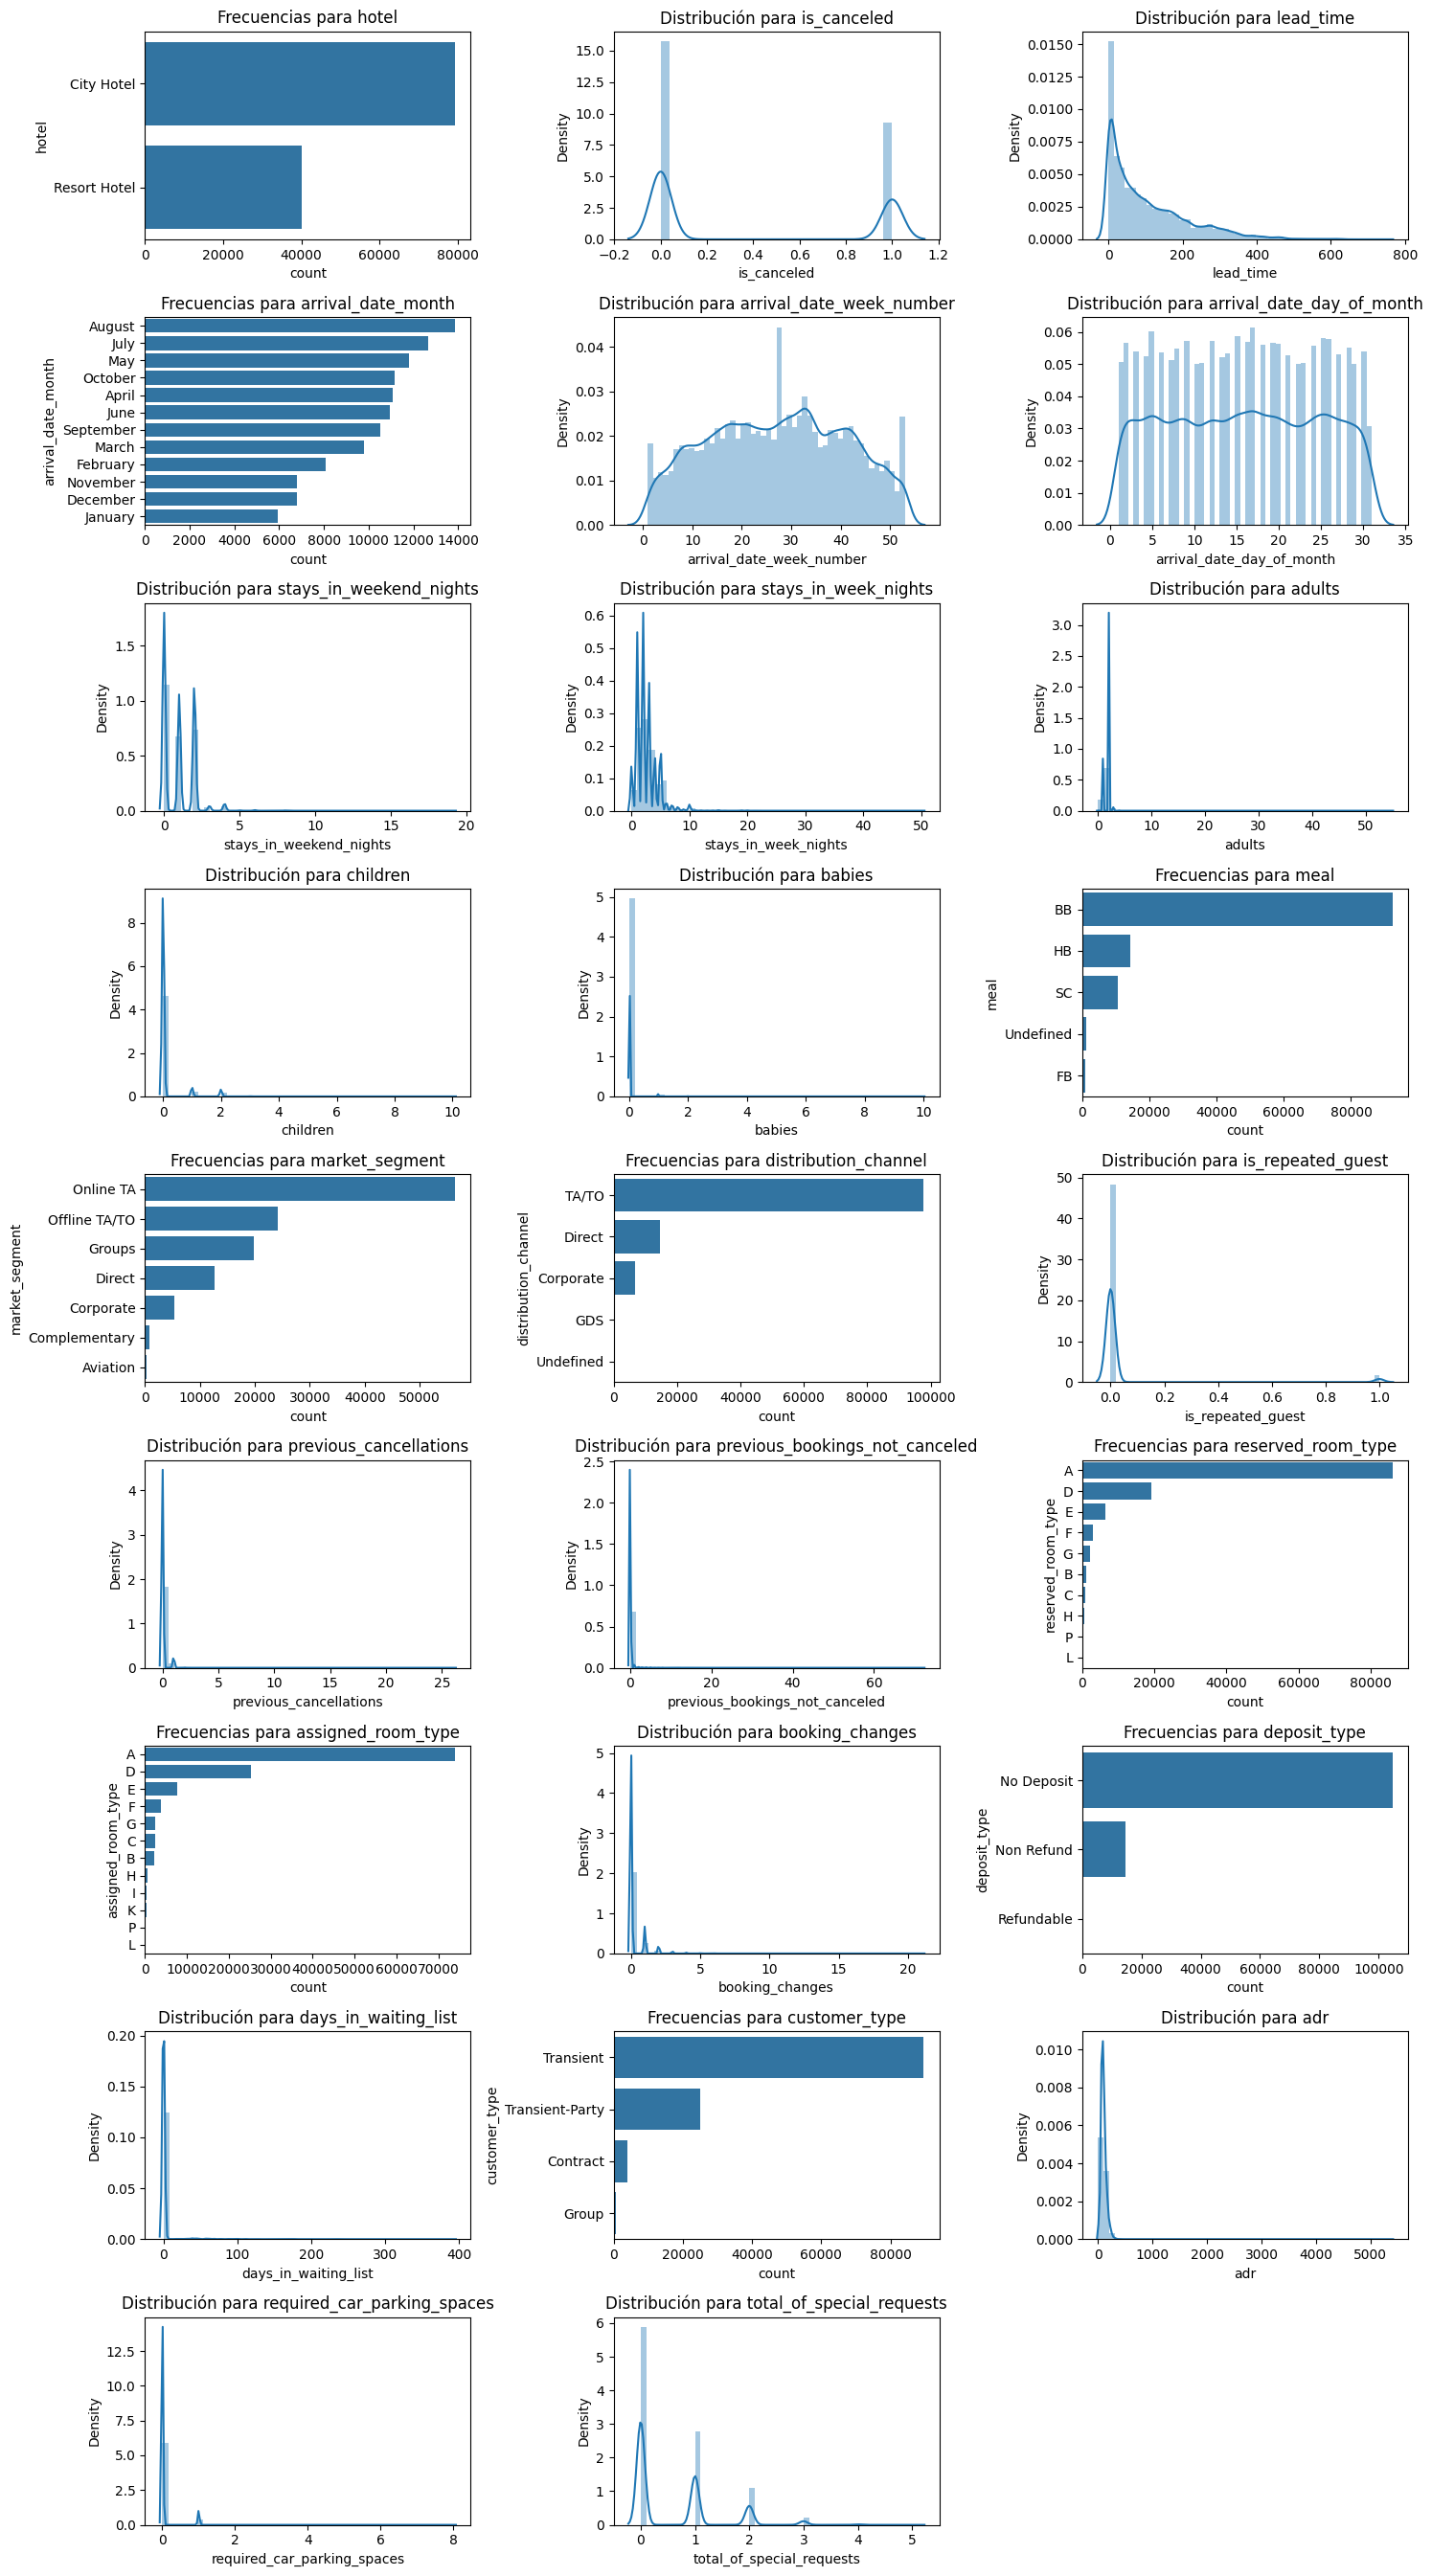

In [ ]:
graficos(calidad_datos(df), df, df.columns)

###3.a. Se Seleccionarán 5 variables que que sean considas relevantes (que no sean la variable adr) con respecto a cancelar una reserva.

In [ ]:
variables = ['lead_time',
            'market_segment',
            'stays_in_week_nights',
            'hotel',
            'customer_type']

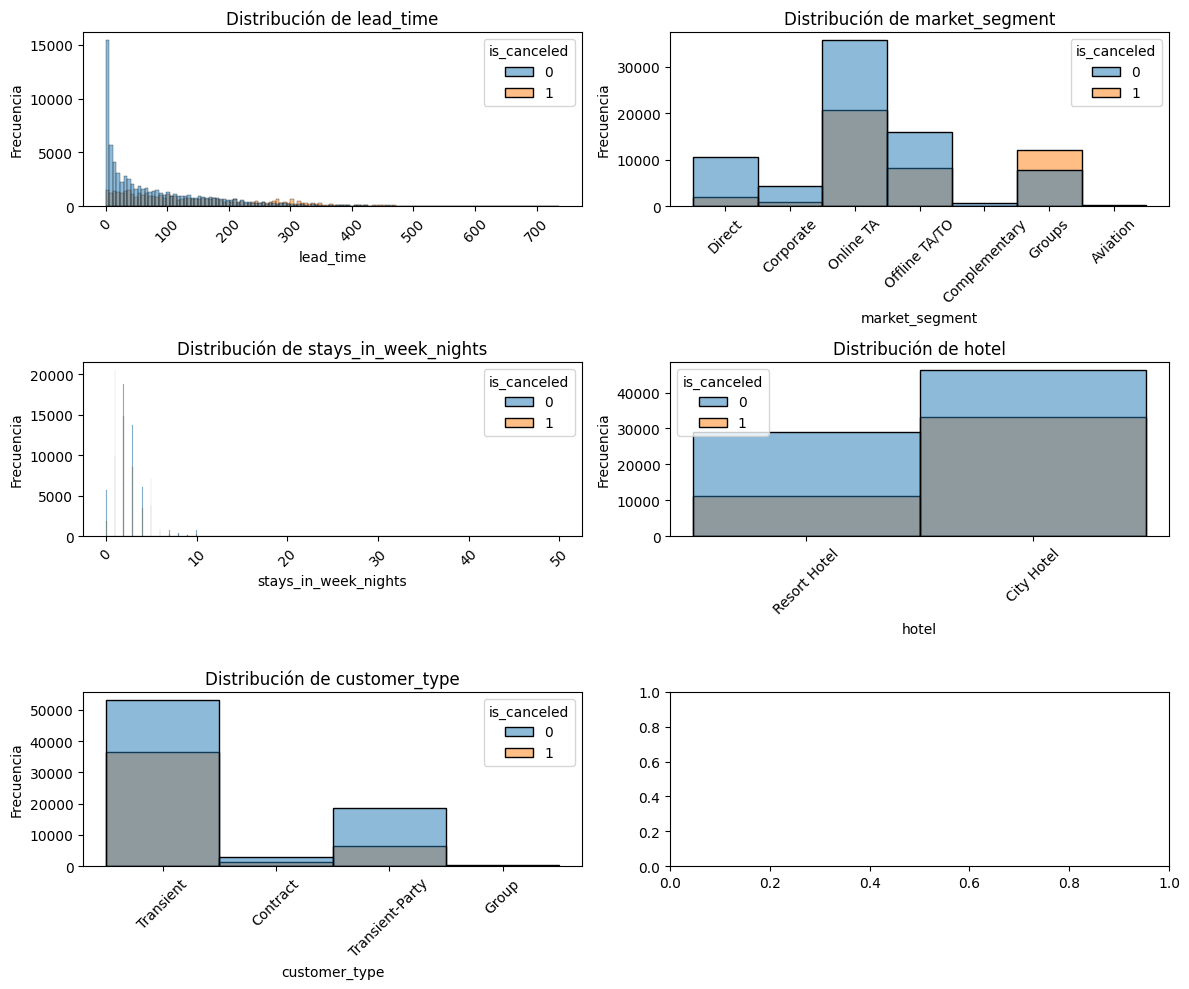

In [ ]:
ncols = 2
nrows = (len(variables) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 10))
axes = axes.flatten()

for i, variable in enumerate(variables):
    sns.histplot(data = df, x = variable, hue='is_canceled', ax = axes[i])
    axes[i].set_title(f'Distribución de {variable}')
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

###**3.b.** Se construirá un histograma para la variable adr con reservas canceladas y no canceladas, comentando el resultado obtenido.

<Axes: xlabel='adr', ylabel='Count'>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


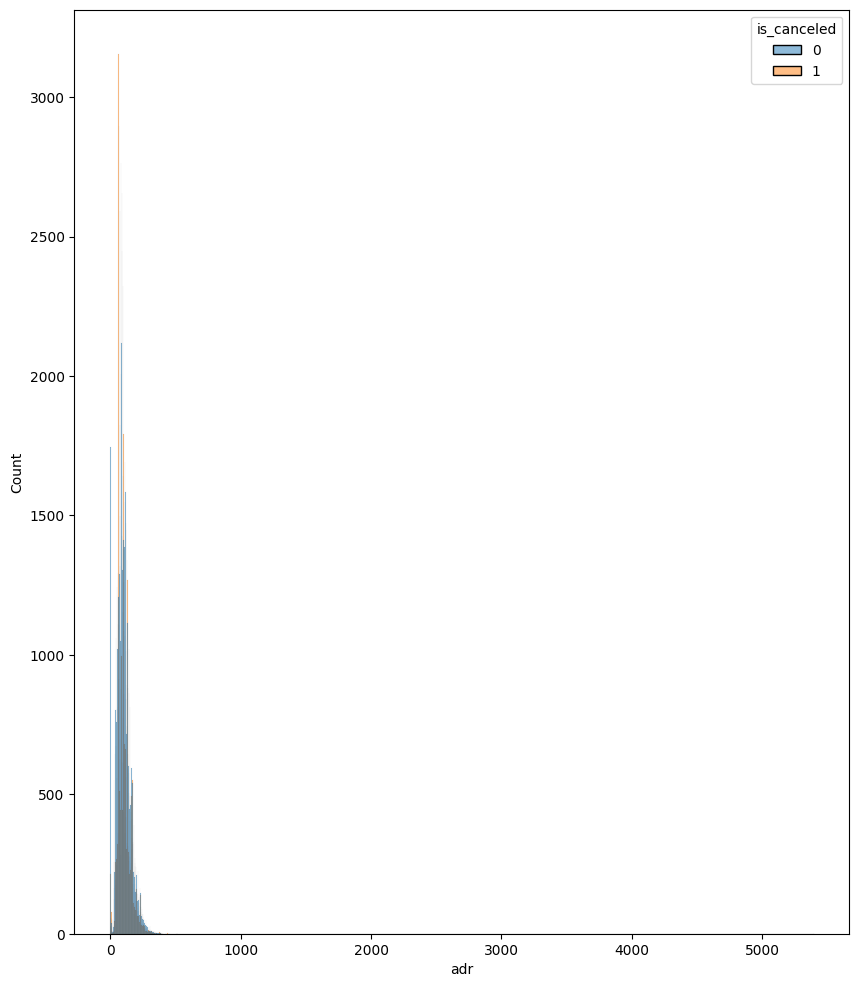

In [ ]:
fig, ax = plt.subplots(figsize=(10,12))
sns.histplot(data = df, x = 'adr', hue='is_canceled', ax = ax)


###3.c. Se verificará la presencia de outlier para la variable adr. En caso que presente valores extremos se indicará la cantidad de outliers por arriba, y la cantidad deoutlier por abajo. Sólo se eliminarán los tres valores más extremos en ambos casos, los demás serán reemplazados por el valor promedio de la variable.

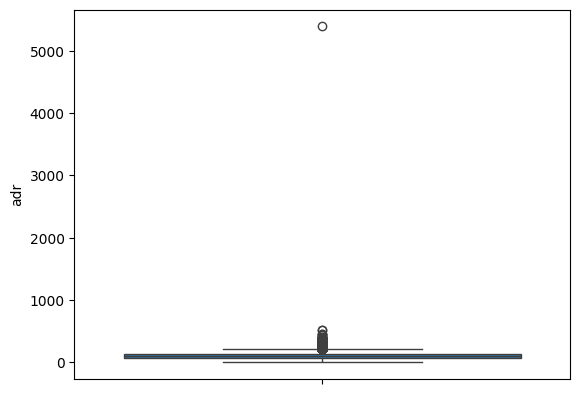

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
48515,City Hotel,1,35,March,13,25,0,1,2,0.0,...,0,A,A,1,Non Refund,0,Transient,5400.0,0,0
111403,City Hotel,0,0,May,19,9,0,1,1,0.0,...,0,A,G,0,No Deposit,0,Transient,510.0,0,0
15083,Resort Hotel,0,1,July,29,15,0,1,2,0.0,...,1,A,C,0,No Deposit,0,Transient,508.0,1,0


In [ ]:
identifica_outliers(df, 'adr').sort_values('adr', ascending=False).head(3)

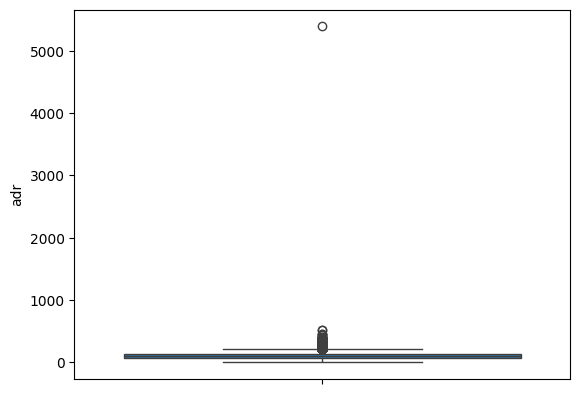

In [ ]:
df.drop(identifica_outliers(df, 'adr').sort_values('adr', ascending=False).head(3).index, inplace = True)

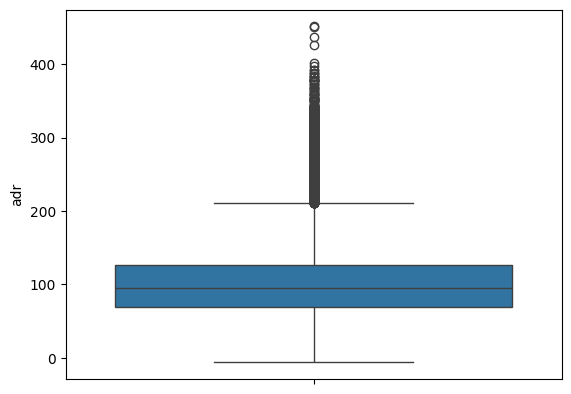

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
115428,City Hotel,0,68,July,27,3,1,2,2,2.0,...,0,G,G,2,No Deposit,0,Transient,211.08,0,1
38671,Resort Hotel,0,23,July,29,21,2,3,2,0.0,...,0,F,F,0,No Deposit,0,Transient,211.12,1,1
27439,Resort Hotel,0,136,August,35,22,2,5,2,2.0,...,0,C,C,0,No Deposit,0,Transient,211.16,1,0


In [ ]:
identifica_outliers(df, 'adr').sort_values('adr', ascending=True).head(3)

Determinando Q1, Q3, IQR, lower_bound y upper_bound para el atributo **adr**

In [ ]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



calcula el promedio del atributo 'adr' para los valores que se encuentran dentro del rango lower_bound y upper_bound

In [ ]:
promedio_adr_dentro_rango = df.loc[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound), 'adr'].mean()

Reemplazo de valores outliers por el promedio calculado entre lower_bound y upper_bound

In [ ]:
df['adr'] = np.where((df['adr'] < lower_bound) | (df['adr'] > upper_bound), promedio_adr_dentro_rango, df['adr'])

A continuación se presenta el efecto conseguido con la transformación que se acaba de realizar:

<Axes: xlabel='adr', ylabel='Count'>

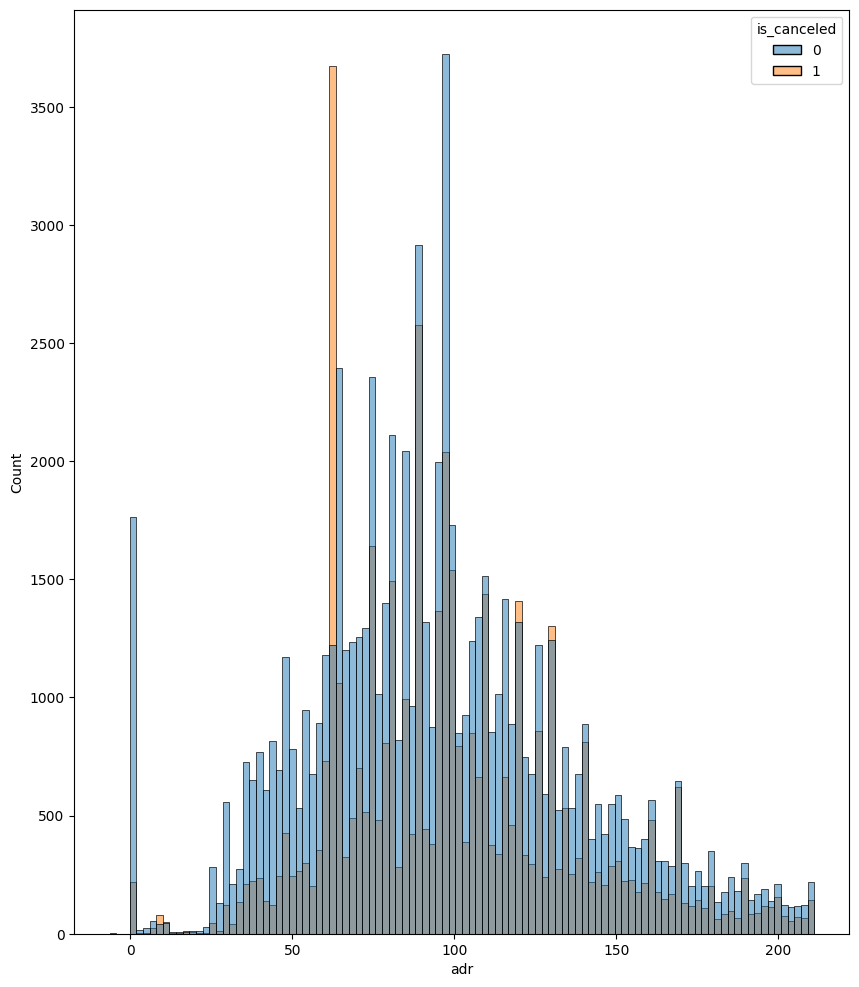

In [ ]:
fig, ax = plt.subplots(figsize=(10,12))
sns.histplot(data = df, x = 'adr', hue='is_canceled', ax = ax)

###3.e. División del Dataset en set de entrenamiento y test

In [ ]:
var_cat = []
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Variables categóricas:")
for col in categorical_features:
    var_car = var_cat.append(col)
    print(f"- {col}")

Variables categóricas:
- hotel
- arrival_date_month
- meal
- market_segment
- distribution_channel
- reserved_room_type
- assigned_room_type
- deposit_type
- customer_type


In [ ]:
var_cat

['hotel',
 'arrival_date_month',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type']

In [ ]:
df = pd.get_dummies(df, columns=var_cat, dtype=int)

In [ ]:
df

,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,27,1,0,0,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0,737,27,1,0,0,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,7,27,1,0,1,1,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,13,27,1,0,1,1,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0,14,27,1,0,2,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,23,35,30,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119386,0,102,35,31,2,5,3,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119387,0,34,35,31,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119388,0,109,35,31,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0


Separando el dataset en X e Y

In [ ]:
X = df.drop(columns = 'is_canceled')
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=4)

Escalando los conjuntos de entrenamiento y test de las variables independientes

In [ ]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

##4. Implementación de modelos de redes neuronales

###4.1. Primer modelo con funciones de activación tanh, relu y tanh en las capas ocultas.

Se define función crear_model para continuar con el desarrollo

In [ ]:
def create_model(n_features, activations,n_hiden_layers, n_neurons,
                 k_initializer = HeNormal(), bias_initializer ='zeros'):

  ann1 = Sequential()
  ann1.add(keras.Input(shape = (n_features,))) #Establece la capa de entrada con n_features neuronas. Para establecer un escalar se escribe (x,)

  constraint = max_norm(3)

  for idx, hl in enumerate(range(1, n_hiden_layers+1)): #hl: hidden layer
    ann1.add(
        Dense(
            units = n_neurons,
            use_bias = True,
            activation = activations[idx],
            kernel_initializer = k_initializer[idx],
            bias_initializer = bias_initializer[idx],
            kernel_constraint = constraint,

        )
    )
  # A continuación se defina la capa de salida.
  # En este caso al ser un problema de clasificación
  # Se considerará sólo 1 neurona de salida

  ann1.add(
        Dense(
            units = 1,
            use_bias = True,
            activation = 'sigmoid',
            kernel_initializer = 'glorot_normal',
            bias_initializer = 'zeros',
            kernel_constraint = constraint
        )
    )
  return ann1

In [ ]:
X_train.shape

(79986, 76)

In [ ]:
X_train[:1]

array([[ 0.74978301,  0.13373115,  0.02066581,  0.07418389, -0.78949921,
         0.25280327, -0.26125683, -0.08341292, -0.18113636, -0.10366841,
        -0.09099039,  1.19571476, -0.13117899,  0.69806418, -0.25725797,
         0.54336027,  0.71166673, -0.71166673, -0.32033797, -0.36177318,
        -0.24504905, -0.2684568 , -0.22964811,  2.88976004, -0.31621689,
        -0.29842895, -0.3303479 , -0.24602217, -0.32268133, -0.31032135,
        -1.84592194, -0.08229049,  2.69579057, -0.31374703, -0.09839726,
        -0.04491004, -0.07737356, -0.21737628, -0.34391666,  2.23546432,
        -0.50253433, -0.94696951, -0.24533557, -0.37460328, -0.0398786 ,
         0.47079213, -0.00353587,  0.62306662, -0.09537332, -0.08888647,
        -0.43711034, -0.24266081, -0.15720277, -0.13356939, -0.07062667,
        -0.00707186, -0.01060813,  0.7853203 , -0.13501666, -0.14300651,
        -0.52017989, -0.26687439, -0.17973275, -0.14744949, -0.07704584,
        -0.05542966, -0.04918088, -0.00353587, -0.0

In [ ]:
ann1 = create_model(
    n_features = X_train.shape[1],
    activations = ['tanh', 'relu', 'tanh'],
    n_hiden_layers = 3,
    n_neurons = 20,
    k_initializer = ['glorot_normal','he_normal', 'glorot_normal'],
    bias_initializer = ['zeros'] * 3

    )
ann1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │         1,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401 (9.38 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 0 (0.00 B)

La metodología utilizada menciona que serán considerados los siguiente parámetros:

In [ ]:
EPOCHS = 10

ann1.compile(
    optimizer = 'sgd',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
    #batch_size= 500 lote de entrenamiento
)


A continuación se entrena el modelo

In [ ]:
history1 = ann1.fit(
    X_train, y_train,
    epochs = EPOCHS,
    validation_data = (X_test, y_test)

)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7522 - loss: 0.5015 - val_accuracy: 0.7948 - val_loss: 0.4390
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7998 - loss: 0.4290 - val_accuracy: 0.8055 - val_loss: 0.4183
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8063 - loss: 0.4143 - val_accuracy: 0.8095 - val_loss: 0.4081
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8104 - loss: 0.4041 - val_accuracy: 0.8098 - val_loss: 0.4015
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8142 - loss: 0.3965 - val_accuracy: 0.8154 - val_loss: 0.3952
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8169 - loss: 0.3909 - val_accuracy: 0.8189 - val_loss: 0.3917
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8197 - loss: 0.3865 - val_accuracy: 0.8193 - val_loss: 0.3895
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8215 - loss: 0.38

In [ ]:
yhat = ann1.predict(X_test)
yhat_class = np.where(yhat > 0.5, 1, 0)

print(classification_report(y_test, yhat_class))

1232/1232 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     24777
           1       0.82      0.66      0.73     14620

    accuracy                           0.82     39397
   macro avg       0.82      0.79      0.80     39397
weighted avg       0.82      0.82      0.82     39397



###4.2 Segundo modelo sólo funciones tanh en sus capas ocultas.

In [ ]:
ann2 = create_model(
    n_features = X_train.shape[1],
    activations = ['tanh', 'tanh', 'tanh'],
    n_hiden_layers = 3,
    n_neurons = 20,
    k_initializer = ['glorot_normal','glorot_normal', 'glorot_normal'],
    bias_initializer = ['zeros'] * 3

    )
ann2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 20)             │         1,540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401 (9.38 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

ann2.compile(
    optimizer = 'sgd',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
    #batch_size= 500 lote de entrenamiento
)

In [ ]:
history2 = ann2.fit(
    X_train, y_train,
    epochs = EPOCHS,
    validation_data = (X_test, y_test)
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7711 - loss: 0.4801 - val_accuracy: 0.8000 - val_loss: 0.4330
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8029 - loss: 0.4249 - val_accuracy: 0.8094 - val_loss: 0.4140
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8079 - loss: 0.4097 - val_accuracy: 0.8137 - val_loss: 0.4041
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8129 - loss: 0.4016 - val_accuracy: 0.8166 - val_loss: 0.3998
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8150 - loss: 0.3966 - val_accuracy: 0.8150 - val_loss: 0.3950
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.8167 - loss: 0.3931 - val_accuracy: 0.8187 - val_loss: 0.3926
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8169 - loss: 0.3903 - val_accuracy: 0.8182 - val_loss: 0.3916
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8183 - loss: 0.388

In [ ]:
yhat = ann2.predict(X_test)
yhat_class = np.where(yhat > 0.5, 1, 0)

print(classification_report(y_test, yhat_class))

1232/1232 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     24777
           1       0.81      0.66      0.73     14620

    accuracy                           0.82     39397
   macro avg       0.82      0.79      0.80     39397
weighted avg       0.82      0.82      0.81     39397



A continuación, se mostrará la curva de accuracy para cada modelo en cada época de entrenamiento.

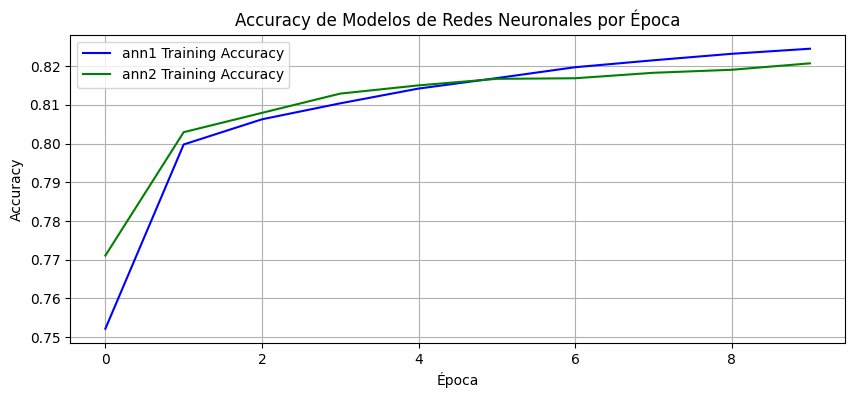

In [ ]:
plt.figure(figsize=(10, 4))

# Plot history for ann1
plt.plot(history1.history['accuracy'], label='ann1 Training Accuracy', color='blue')

# Plot history for ann2
plt.plot(history2.history['accuracy'], label='ann2 Training Accuracy', color='green')

plt.title('Accuracy de Modelos de Redes Neuronales por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**CONCLUSION:** La red neuronal que utiliza **relu** como función de activación en las capas ocultas, presenta un Acuracy mayor, en comparación con el modelo que utiliza **tanh** para activar las neuronas de las capas ocultas.

In [ ]:
def create_model_grilla(n_hidden_layers=2, n_neurons=80,
                        activation='relu', dropout_rate=.001,
                        k_initializer='glorot_normal', meta={}):

    n_features_in_ = meta["n_features_in_"]
    X_shape_ = meta["X_shape_"]

    # Restricción para garantizar que la norma de cada
    # vector de pesos no exceda de tres.
    constraint = max_norm(3)

    # Arquitectura secuencial
    ann_tmp = Sequential()

    # Capa de entrada
    ann_tmp.add(keras.Input(shape=(n_features_in_, )))

    # Capas ocultas
    for hl in range(n_hidden_layers):
        ann_tmp.add(
            Dense(
                units=n_neurons,
                use_bias=True,
                activation=activation,
                kernel_initializer=k_initializer,
                bias_initializer='zeros',
                kernel_constraint=constraint
            )
        )
        ann_tmp.add(
            Dropout(rate=dropout_rate)
        )

    # Capa de salida
    ann_tmp.add(
        Dense(
            units=1,
            use_bias=True,
            activation='sigmoid',
            kernel_initializer='glorot_normal',
            bias_initializer='zeros',
            kernel_regularizer=l1(l1=0.001),
            kernel_constraint=constraint
        )
    )

    return ann_tmp

In [ ]:
clf = KerasClassifier(
    create_model_grilla,
    loss='binary_crossentropy',
    verbose=1,
    metrics=['accuracy'],
    validation_split=.33,
)

In [ ]:
# Espacio en el que se búsca los hiper parámetros óptimos
param_grid = {
    'model__n_hidden_layers': [3, 4],
    'model__n_neurons': [20],
    'model__activation': ['tanh'],
    'batch_size': [500],
    'epochs': [20],
    'optimizer': ['SGD', 'Adam'],
    'optimizer__learning_rate': [0.03, 0.06],
    'model__dropout_rate': [0.001],
    'model__k_initializer': ['glorot_normal', 'glorot_uniform']
}

In [ ]:
# GridSearchCV
grid = GridSearchCV(estimator=clf, param_grid=param_grid,
    scoring='accuracy', cv=3, verbose=0, n_jobs=-1)

grid_result = grid.fit(X_train, y_train)

# Mostrar mejores hiper parámetros encontrados
print(f"Mejor accuracy: {grid_result.best_score_}, con los parámetros: {grid_result.best_params_}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7931 - loss: 0.4400 - val_accuracy: 0.8118 - val_loss: 0.4095
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8074 - loss: 0.4089 - val_accuracy: 0.8129 - val_loss: 0.4020
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8114 - loss: 0.4013 - val_accuracy: 0.8078 - val_loss: 0.4072
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8132 - loss: 0.4016 - val_accuracy: 0.8114 - val_loss: 0.4041
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8139 - loss: 0.3999 - val_accuracy: 0.8104 - val_loss: 0.4007
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8149 - loss: 0.3972 - val_accuracy: 0.8150 - val_loss: 0.4034
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8161 - loss: 0.3980 - val_accuracy: 0.8136 - val_loss: 0.4000
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8163 - loss: 0.3952 - val_accuracy: 0

In [ ]:
yhat_class = grid_result.best_estimator_.predict(X_test)
print(classification_report(y_test, yhat_class))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     24777
           1       0.80      0.68      0.74     14620

    accuracy                           0.82     39397
   macro avg       0.82      0.79      0.80     39397
weighted avg       0.82      0.82      0.82     39397



79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


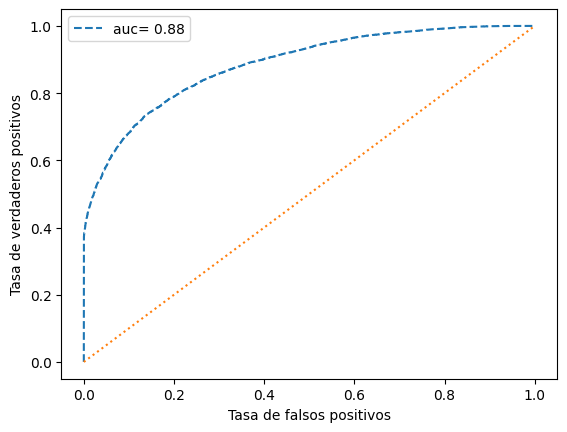

In [ ]:
yhat_proba = grid_result.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, yhat_proba)
auc = np.round(roc_auc_score(y_test, yhat_proba), 2)

plt.plot(fpr, tpr, '--', label=f'auc= {auc}')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.plot([0, 1], [0, 1], ':')
plt.legend();

Del conjunto original (sin los valores excluidos) escoge al azar 5 observaciones en que “deposit_type_Non Refund” sea uno, y con esto realiza una predicción usando el mejor modelo encontrado por la búsqueda de grilla anterior.

In [ ]:
df_original

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,27,1,0,0,2,0.0,...,0,C,C,3,No Deposit,0,Transient,0.000000,0,0
1,Resort Hotel,0,737,July,27,1,0,0,2,0.0,...,0,C,C,4,No Deposit,0,Transient,0.000000,0,0
2,Resort Hotel,0,7,July,27,1,0,1,1,0.0,...,0,A,C,0,No Deposit,0,Transient,75.000000,0,0
3,Resort Hotel,0,13,July,27,1,0,1,1,0.0,...,0,A,A,0,No Deposit,0,Transient,75.000000,0,0
4,Resort Hotel,0,14,July,27,1,0,2,2,0.0,...,0,A,A,0,No Deposit,0,Transient,98.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,August,35,30,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,96.140000,0,0
119386,City Hotel,0,102,August,35,31,2,5,3,0.0,...,0,E,E,0,No Deposit,0,Transient,97.038976,0,2
119387,City Hotel,0,34,August,35,31,2,5,2,0.0,...,0,D,D,0,No Deposit,0,Transient,157.710000,0,4
119388,City Hotel,0,109,August,35,31,2,5,2,0.0,...,0,A,A,0,No Deposit,0,Transient,104.400000,0,0


In [ ]:
var_cat2 = []
categorical_features = df_original.select_dtypes(include=['object']).columns.tolist()
print("Variables categóricas:")
for col in categorical_features:
    var_car = var_cat2.append(col)
    print(f"- {col}")

Variables categóricas:
- hotel
- arrival_date_month
- meal
- market_segment
- distribution_channel
- reserved_room_type
- assigned_room_type
- deposit_type
- customer_type


In [ ]:
df_original = pd.get_dummies(df_original, columns=var_cat2, dtype=int)

In [ ]:
df_original

,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,27,1,0,0,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0,737,27,1,0,0,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,7,27,1,0,1,1,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,13,27,1,0,1,1,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0,14,27,1,0,2,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,23,35,30,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119386,0,102,35,31,2,5,3,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119387,0,34,35,31,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
119388,0,109,35,31,2,5,2,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
n_obs = 5
sampled_data = df[df['deposit_type_Non Refund']==0].sample(n_obs, random_state=42)
X_test_new_features = sampled_data.drop(columns='is_canceled')
y_test_new_true = sampled_data['is_canceled']

In [ ]:
X_test_new_scaled = ss.transform(X_test_new_features)

yhat_new = grid_result.best_estimator_.predict(X_test_new_scaled)
print(classification_report(y_test_new_true, yhat_new))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.33      1.00      0.50         1

    accuracy                           0.60         5
   macro avg       0.67      0.75      0.58         5
weighted avg       0.87      0.60      0.63         5

